# DS4420 Final Project — MLP Classifier
**Authors:** Gavin Bond, Benjamin Kataoka, Preetish Paul

## Overview

This notebook builds and evaluates a Multilayer Perceptron (MLP) classifier on the combined 2024/2025 Stack Overflow Developer Survey data. The goal is to predict a developer's level of trust in AI-generated output (`AIAcc`) based on their professional background and AI usage characteristics.

Unlike our Bayesian model (which is implemented separately in R), the MLP is not trying to give us interpretable coefficients — its job is to capture potentially nonlinear and interactive patterns in the data that a simpler model might miss. For example, the relationship between years of experience and distrust might only emerge when combined with certain org sizes or AI usage patterns; the MLP handles that naturally.

The target variable `AIAcc` has five ordered categories:
- Highly trust
- Somewhat trust
- Neither trust nor distrust
- Somewhat distrust
- Highly distrust

This is a **multiclass classification** problem. The network outputs a probability distribution over all five classes, and we assign the predicted label as whichever class has the highest probability.

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score
)

np.random.seed(42)

## Load the Preprocessed Data

We're loading `combined_survey.csv`, which was built in `preprocessing.ipynb`. That file already handles combining the 2024 and 2025 survey years, filtering to professional developers only, and harmonizing the three columns whose response options changed between years. We don't need to redo any of that here — we just load it and go.

In [34]:
df = pd.read_csv("combined_survey.csv")

print("Dataset shape:", df.shape)
print()
print("Target distribution (AIAcc):")
print(df["AIAcc"].value_counts())

Dataset shape: (55118, 14)

Target distribution (AIAcc):
AIAcc
Somewhat trust                19144
Neither trust nor distrust    13582
Somewhat distrust             13536
Highly distrust                7490
Highly trust                   1366
Name: count, dtype: int64


## Define Features and Target

The features we're using were chosen because they map directly to the predictors described in our research question: years of coding experience, work experience, age, developer type, education level, org size, and a set of AI-attitude variables (whether they use AI, their general sentiment toward it, whether they feel it threatens their job, etc.).

We drop the `year` column as a feature since it's just a data provenance tag and isn't conceptually meaningful as a predictor of trust.

The target `AIAcc` stays as a five-class variable. We considered collapsing it into a binary (distrust vs. not distrust) but decided to keep all five categories — the distinction between "somewhat distrust" and "highly distrust" is meaningful, and collapsing it would throw away information. The MLP handles five classes just fine.

In [36]:
TARGET = "AIAcc"

FEATURES = [
    "YearsCode", "WorkExp", "Age",
    "DevType", "EdLevel", "OrgSize",
    "AISelect", "AISent", "AIThreat",
    "RemoteWork", "AIComplex", "ICorPM"
]

# drop any rows where the target is missing 
# (already handled in preprocessing, but just being safe)
df = df[df[TARGET].notna()].copy()

print(f"Working with {len(df)} rows and {len(FEATURES)} features.")

Working with 55118 rows and 12 features.


## Preprocessing

### Clean Numeric Columns

`YearsCode` is stored as a string because the survey has special text responses for edge cases like "Less than 1 year" and "More than 50 years". We convert those to numeric equivalents (0.5 and 50) and then coerce everything else to a float. Any remaining non-numeric entries become NaN, which we handle with median imputation below.

In [38]:
def clean_years(series):
    """Convert the YearsCode string column to a numeric float."""
    return pd.to_numeric(
        series.replace({
            "Less than 1 year": "0.5",
            "More than 50 years": "50"
        }),
        errors="coerce"
    )

df["YearsCode"] = clean_years(df["YearsCode"])

### Impute Missing Values

There are missing values scattered across most columns since not every survey respondent answered every question. For numeric columns we use the median (more robust than the mean given some skewed distributions like years of experience). For categorical columns we fill with the string `"Missing"` so the encoder treats non-response as its own category rather than dropping those rows.

In [40]:
numeric_cols = df[FEATURES].select_dtypes(include=np.number).columns.tolist()
categorical_cols = [c for c in FEATURES if c not in numeric_cols]

print("Numeric features:", numeric_cols)
print("Categorical features:", categorical_cols)

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    df[col] = df[col].fillna("Missing").astype(str)

Numeric features: ['YearsCode', 'WorkExp']
Categorical features: ['Age', 'DevType', 'EdLevel', 'OrgSize', 'AISelect', 'AISent', 'AIThreat', 'RemoteWork', 'AIComplex', 'ICorPM']


### Reduce High-Cardinality Categorical Columns

Some columns like `DevType` allow multiple selections separated by semicolons, and `Age` has a handful of unusual entries. More importantly, after one-hot encoding, rare categories contribute almost no signal but add columns to the feature matrix. We replace any category that appears fewer than 200 times with `"Other"` to keep the encoded feature space manageable. The threshold of 200 was chosen somewhat arbitrarily but felt reasonable given our ~55k row dataset.

In [42]:
def reduce_categories(series, min_count=200):
    """Replace infrequent categories with 'Other' to avoid sparse dummy columns."""
    counts = series.value_counts()
    keep = counts[counts >= min_count].index
    return series.where(series.isin(keep), other="Other")

for col in categorical_cols:
    df[col] = reduce_categories(df[col])

print("Category counts after reduction:")
for col in categorical_cols:
    print(f"  {col}: {df[col].nunique()} unique values")

Category counts after reduction:
  Age: 7 unique values
  DevType: 27 unique values
  EdLevel: 10 unique values
  OrgSize: 10 unique values
  AISelect: 4 unique values
  AISent: 7 unique values
  AIThreat: 4 unique values
  RemoteWork: 4 unique values
  AIComplex: 7 unique values
  ICorPM: 3 unique values


### One-Hot Encode and Scale

MLPs require all-numeric input. We one-hot encode the categorical features using `pd.get_dummies` with `drop_first=True` to avoid perfect multicollinearity. After that, all features are standardized to zero mean and unit variance — this is important for neural networks because large differences in feature scale can cause the gradient updates to behave poorly.

In [44]:
X = pd.get_dummies(df[FEATURES], drop_first=True)

# encode the 5-class target as integers 0-4
le = LabelEncoder()
y = le.fit_transform(df[TARGET])

print("Encoded feature matrix shape:", X.shape)
print()
print("Class label mapping:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} -> {cls}")

Encoded feature matrix shape: (55118, 75)

Class label mapping:
  0 -> Highly distrust
  1 -> Highly trust
  2 -> Neither trust nor distrust
  3 -> Somewhat distrust
  4 -> Somewhat trust


## Train/Test Split

We use an 80/20 split with stratification on the target variable. Stratifying is especially important here because the class distribution is imbalanced — "Highly trust" has only ~1,400 cases while "Somewhat trust" has ~19,000. Without stratification we risk the test set having a different class balance than the training set, which would give us misleading evaluation metrics.

In [46]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f"Training set: {X_train_scaled.shape[0]} rows")
print(f"Test set:     {X_test_scaled.shape[0]} rows")

Training set: 44094 rows
Test set:     11024 rows


## Handle Class Imbalance via Oversampling

Because the "Highly trust" class is so small relative to the others, a naive MLP will just learn to mostly predict "Somewhat trust" and still get decent overall accuracy. The ideal fix would be to pass `class_weight` directly, but sklearn's `MLPClassifier` is one of the few estimators in the library that doesn't support it — and `sample_weight` in the fit call isn't supported either.

Instead, we handle the imbalance by **oversampling the training set**: for each minority class, we randomly resample with replacement until every class has the same number of rows as the majority class. This is applied only to the training data — the test set stays untouched so our evaluation reflects the real-world distribution.

In [48]:
from sklearn.utils import resample

# combine into a dataframe so we can split by class
train_df = pd.DataFrame(X_train_scaled).copy()
train_df["__label__"] = y_train

majority_size = train_df["__label__"].value_counts().max()

resampled_parts = []
for cls in train_df["__label__"].unique():
    cls_subset = train_df[train_df["__label__"] == cls]
    if len(cls_subset) < majority_size:
        cls_subset = resample(
            cls_subset,
            replace=True,
            n_samples=majority_size,
            random_state=42
        )
    resampled_parts.append(cls_subset)

train_balanced = pd.concat(resampled_parts).sample(frac=1, random_state=42)

X_train_bal = train_balanced.drop(columns="__label__").values
y_train_bal = train_balanced["__label__"].values

print("Balanced class distribution:")
unique, counts = np.unique(y_train_bal, return_counts=True)
for cls, cnt in zip(unique, counts):
    print(f"  {le.classes_[cls]}: {cnt}")

Balanced class distribution:
  Highly distrust: 15315
  Highly trust: 15315
  Neither trust nor distrust: 15315
  Somewhat distrust: 15315
  Somewhat trust: 15315


## Train the MLP

We use scikit-learn's `MLPClassifier`. Since this is a prebuilt model, we don't need to implement backprop by hand — we just need to configure it thoughtfully.

**Architecture choices:**
- Two hidden layers of size 128 and 64. The first layer is wider to capture the large number of one-hot encoded features; the second layer compresses that representation before the output.
- ReLU activation, which is the standard default and works well in practice.
- `adam` optimizer, which adapts the learning rate during training and tends to converge faster than vanilla SGD.
- `max_iter=200` gives the optimizer enough epochs to converge without running forever.
- `early_stopping=True` with `validation_fraction=0.1` holds out 10% of the (now balanced) training data as a validation set and stops training early if validation loss stops improving for 10 consecutive epochs. This is our main guard against overfitting.

In [50]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    activation="relu",
    solver="adam",
    max_iter=200,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10,
    random_state=42,
    verbose=True
)

mlp.fit(X_train_bal, y_train_bal)

print(f"\nTraining stopped after {mlp.n_iter_} iterations.")

Iteration 1, loss = 1.13594805
Validation score: 0.524288
Iteration 2, loss = 1.04383219
Validation score: 0.537085
Iteration 3, loss = 1.00591313
Validation score: 0.560198
Iteration 4, loss = 0.97254752
Validation score: 0.568033
Iteration 5, loss = 0.94374628
Validation score: 0.574824
Iteration 6, loss = 0.91591342
Validation score: 0.582659
Iteration 7, loss = 0.89270671
Validation score: 0.601985
Iteration 8, loss = 0.87243964
Validation score: 0.600548
Iteration 9, loss = 0.85350296
Validation score: 0.598720
Iteration 10, loss = 0.83873299
Validation score: 0.602377
Iteration 11, loss = 0.82242158
Validation score: 0.615696
Iteration 12, loss = 0.80968594
Validation score: 0.622486
Iteration 13, loss = 0.79725664
Validation score: 0.623009
Iteration 14, loss = 0.78606022
Validation score: 0.620789
Iteration 15, loss = 0.77601028
Validation score: 0.629015
Iteration 16, loss = 0.76611877
Validation score: 0.630582
Iteration 17, loss = 0.75803034
Validation score: 0.629146
Iterat

## Training Loss Curve

The loss curve below shows how the training loss decreased over epochs. A steadily decreasing curve that levels off is what we want — it means the model was learning and the optimizer was converging rather than oscillating. If we see the loss plateau very early or never decrease, that would suggest a problem with the architecture or learning rate.

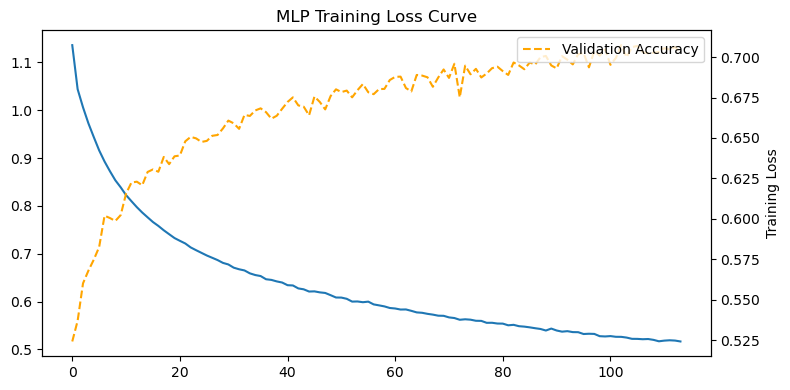

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(mlp.loss_curve_, label="Training Loss")
if mlp.validation_scores_ is not None:
    # validation_scores_ tracks accuracy, not loss — plot it on a secondary axis
    ax2 = plt.gca().twinx()
    ax2.plot(mlp.validation_scores_, color="orange", linestyle="--", label="Validation Accuracy")
    ax2.set_ylabel("Validation Accuracy")
    ax2.legend(loc="lower right")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("MLP Training Loss Curve")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

Training loss decreased smoothly from ~1.13 to ~0.52 over 114 iterations, with no sudden jumps or oscillations, the Adam optimizer converged cleanly. Validation accuracy (orange, right axis) rose quickly in the first ~20 epochs, then plateaued around 0.70 with minor fluctuations for the remainder of training. Early stopping triggered at iteration 114 after 10 consecutive epochs with no meaningful improvement (tol = 0.0001). The gap between still-decreasing training loss and flat validation accuracy suggests the model has extracted the learnable signal from this feature set — additional capacity or training time would not help. There is no sign of overfitting: loss never spikes and validation accuracy never drops off.

## Evaluate on the Test Set

### Classification Report

The classification report gives us precision, recall, and F1-score for each of the five classes. These are the numbers that actually matter for our research question — overall accuracy is a bit misleading when the class distribution is this uneven.

- **Precision**: of the predictions made for a given class, how many were correct?
- **Recall**: of all the true instances of a given class, how many did we catch?
- **F1**: the harmonic mean of precision and recall; useful when you care about both.

In [54]:
y_pred = mlp.predict(X_test_scaled)
y_pred_proba = mlp.predict_proba(X_test_scaled)

print("Overall accuracy:", round(accuracy_score(y_test, y_pred), 4))
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))

Overall accuracy: 0.4267

                            precision    recall  f1-score   support

           Highly distrust       0.42      0.54      0.47      1498
              Highly trust       0.21      0.27      0.23       273
Neither trust nor distrust       0.33      0.30      0.31      2717
         Somewhat distrust       0.38      0.38      0.38      2707
            Somewhat trust       0.56      0.52      0.54      3829

                  accuracy                           0.43     11024
                 macro avg       0.38      0.40      0.39     11024
              weighted avg       0.43      0.43      0.43     11024



Overall accuracy is 42.7%, which is above the ~35% you'd get by always predicting the majority class ("Somewhat trust") and well above the 20% random baseline for five classes.

- "Somewhat trust" performs best (F1 = 0.54, precision = 0.56, recall = 0.52), driven partly by having the largest support (3,829 test samples) and likely because responses in this category share a more coherent feature profile.
- "Highly distrust" achieves an F1 of 0.47 with the highest recall of any class (0.54), meaning the model catches most truly distrustful developers but at the cost of some false positives.
- "Somewhat distrust" and "Neither trust nor distrust" hover around F1 = 0.31–0.38 — these middle categories are the hardest to distinguish because they sit on the boundary between trust and distrust.
- "Highly trust" is the weakest class (F1 = 0.23, precision = 0.21), reflecting both severe minority representation (only 273 test samples) and the difficulty of separating it from "Somewhat trust" even after oversampling.

The macro average F1 of 0.39 confirms uneven per-class performance; the weighted average of 0.43 aligns with overall accuracy.

### Confusion Matrix

The confusion matrix shows exactly where the model is making mistakes. The diagonal entries are correct predictions; everything off the diagonal is an error. We'd expect to see the most confusion between adjacent classes (e.g., "Somewhat distrust" and "Neither trust nor distrust") since those are conceptually closest to each other.

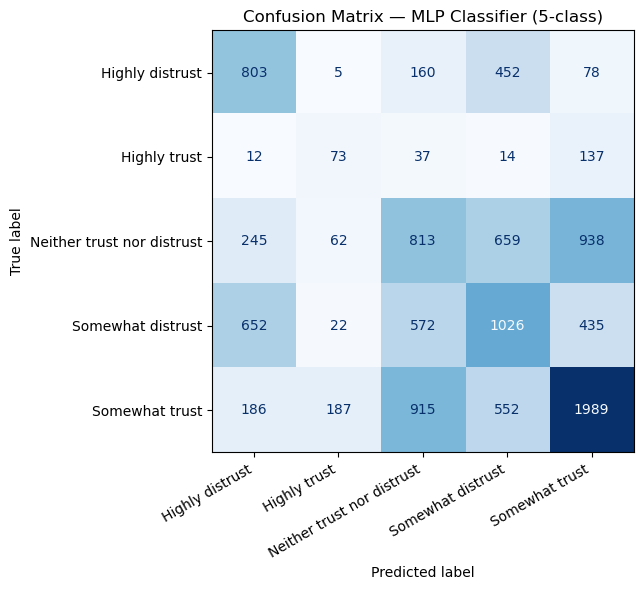

In [ ]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.xticks(rotation=30, ha="right")
plt.title("Confusion Matrix — MLP Classifier (5-class)")
plt.tight_layout()
plt.show()

The diagonal (correct predictions) is strongest for "Somewhat trust" (1,989 correct) and "Somewhat distrust" (1,026 correct), which are the two largest classes. Key misclassification patterns:

- Adjacent-class confusion dominates. "Somewhat distrust" is most often confused with "Highly distrust" (652 cases) and "Neither trust nor distrust" (572 cases) — the model struggles at category boundaries.
- "Neither trust nor distrust" is the most scattered class: only 813 of 2,717 samples are correctly classified, with 938 misclassified as "Somewhat trust" and 659 as "Somewhat distrust." This category acts as a catch-all that the model can't cleanly isolate.
- "Highly trust" has the lowest diagonal count (73/273), with 137 samples pulled into "Somewhat trust" — the model absorbs this small class into its larger neighbor.
- "Somewhat trust" gets misclassified into "Neither trust nor distrust" 915 times, representing the single largest off-diagonal block — the trust/neutral boundary is the fuzziest.

These patterns are consistent with the ordinal nature of the target: errors concentrate one step away on the trust scale rather than at the opposite extreme.

### Per-Class Predicted Probability Distributions

One of the advantages of having a probabilistic output is that we can look at the distribution of predicted probabilities for each class. For each true class, we plot how confident the model was in assigning that class. A good classifier will show high predicted probabilities for the correct class — if the model is consistently uncertain (probabilities hovering around 0.2 for a 5-class problem), that tells us the signal in the data is weak for that class.

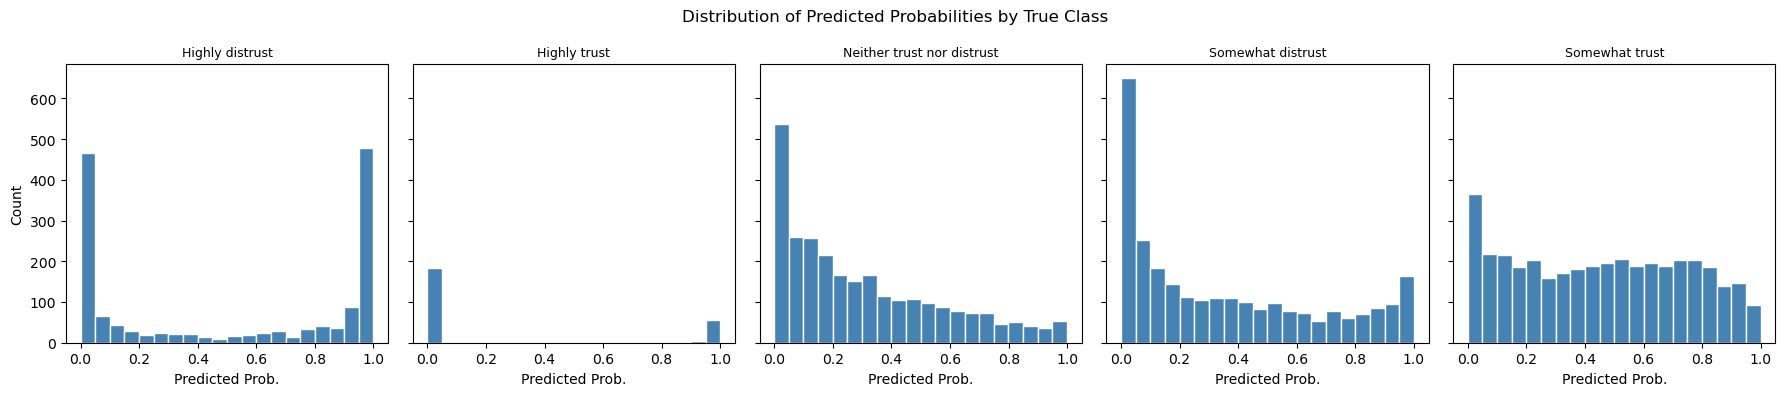

In [ ]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4), sharey=True)

for i, (cls, ax) in enumerate(zip(le.classes_, axes)):
    # for each true class, get the predicted probability assigned to that class
    mask = (y_test == i)
    probs_for_class = y_pred_proba[mask, i]
    ax.hist(probs_for_class, bins=20, color="steelblue", edgecolor="white")
    ax.set_title(cls, fontsize=9)
    ax.set_xlabel("Predicted Prob.")

axes[0].set_ylabel("Count")
fig.suptitle("Distribution of Predicted Probabilities by True Class", fontsize=12)
plt.tight_layout()
plt.show()

These histograms show, for each true class, how much probability the model assigns to the correct label.

- "Highly distrust" shows a clear bimodal pattern: a large spike near 0.0 and another near 1.0. The model is often decisive on this class — when it's confident, it's usually right, but a substantial group also gets assigned near-zero probability (misclassified samples).
- "Highly trust" is strikingly bimodal with most mass at 0.0 — the model rarely assigns high probability to this class, explaining its low recall.
- "Neither trust nor distrust" and "Somewhat distrust" have their probability mass concentrated at low values (0.0–0.2), with a long flat tail. The model is consistently uncertain about these middle classes, assigning them only weak probabilities even when they're the correct answer.
- "Somewhat trust" has the most spread-out distribution, with meaningful density from 0.0 all the way to 1.0. This is the class where the model is most willing to commit high probabilities, consistent with its stronger F1 score.

The takeaway: the model is calibrated well at the extremes but hedges on the middle three categories, treating them almost interchangeably in probability space.

## Feature Importance via Permutation

One of the main limitations of MLPs is that the weights themselves aren't easily interpretable the way, say, logistic regression coefficients are. The standard workaround is **permutation importance**: for each feature, we randomly shuffle that feature's values in the test set and measure how much the model's accuracy drops. If accuracy drops a lot, that feature was important; if it barely changes, the feature wasn't contributing much.

This takes a few minutes to run because we're doing it over all features, but it gives us the closest thing to a feature importance ranking that an MLP can offer — which is directly relevant to our research question about *which factors* predict distrust.

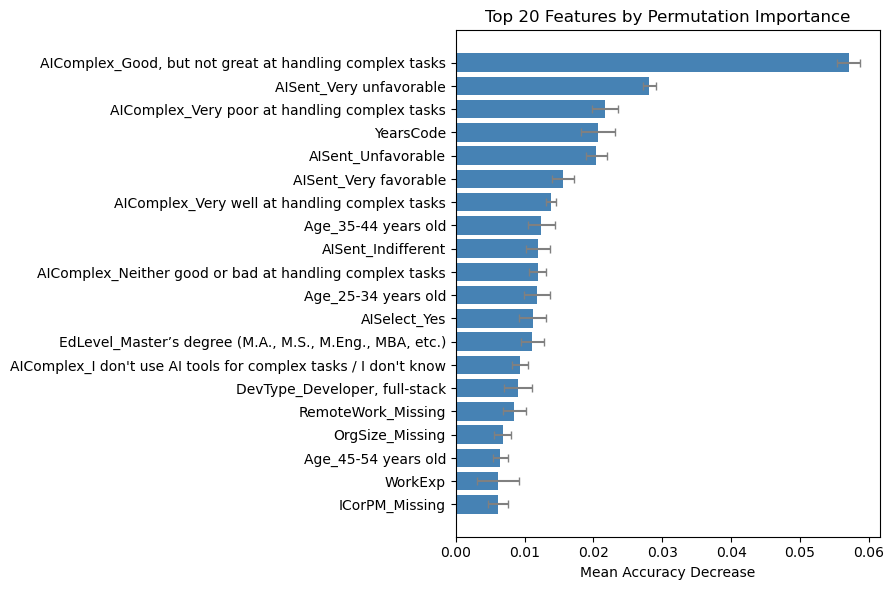

                                                        feature  importance_mean  importance_std
        AIComplex_Good, but not great at handling complex tasks         0.057057        0.001631
                                        AISent_Very unfavorable         0.028120        0.000926
                  AIComplex_Very poor at handling complex tasks         0.021725        0.001874
                                                      YearsCode         0.020673        0.002432
                                             AISent_Unfavorable         0.020446        0.001495
                                          AISent_Very favorable         0.015611        0.001614
                  AIComplex_Very well at handling complex tasks         0.013797        0.000731
                                            Age_35-44 years old         0.012437        0.001925
                                             AISent_Indifferent         0.011910        0.001744
        AIComplex_Neither good

In [ ]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    mlp, X_test_scaled, y_test,
    n_repeats=10,
    random_state=42,
    scoring="accuracy"
)

# build a dataframe and map back to original feature names
perm_df = pd.DataFrame({
    "feature": X.columns,
    "importance_mean": perm_result.importances_mean,
    "importance_std": perm_result.importances_std
}).sort_values("importance_mean", ascending=False)

# show top 20 most important features
top20 = perm_df.head(20)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(
    top20["feature"][::-1],
    top20["importance_mean"][::-1],
    xerr=top20["importance_std"][::-1],
    color="steelblue", ecolor="gray", capsize=3
)
ax.set_xlabel("Mean Accuracy Decrease")
ax.set_title("Top 20 Features by Permutation Importance")
plt.tight_layout()
plt.show()

print(top20[["feature", "importance_mean", "importance_std"]].to_string(index=False))

Permutation importance measures how much test accuracy drops when each feature is randomly shuffled — larger drops mean the feature carries more predictive signal.

- AIComplex (perceived AI capability on complex tasks) dominates the ranking. The single most important feature is "Good, but not great at handling complex tasks" with a mean accuracy decrease of 0.057 — roughly 2–3× more important than any other individual feature. Other AIComplex categories ("Very poor," "Very well," "Neither good or bad") also appear in the top 10. Developers' assessment of how well AI handles complex work is the strongest predictor of their trust level.
- AISent (general sentiment toward AI) is the second most influential feature group. "Very unfavorable" (0.028), "Unfavorable" (0.020), "Very favorable" (0.016), and "Indifferent" (0.012) all rank in the top 10. Negative sentiment features rank higher than positive ones, suggesting that negative AI sentiment is more distinctly associated with distrust than positive sentiment is with trust.
- YearsCode (0.021) is the top demographic feature, indicating that coding experience provides meaningful signal beyond attitudes alone.
- Age groups (35–44 at 0.012, 25–34 at 0.012, 45–54 at 0.006) show moderate importance — mid-career developers are somewhat more predictable in their trust patterns.
- AISelect_Yes (0.011) and EdLevel_Master's (0.011) round out the mid-tier, suggesting that whether a developer has actively chosen to use AI tools, and their education level, contribute to trust prediction.
- DevType, RemoteWork, OrgSize, ICorPM, WorkExp sit at the bottom of the top 20 with importance values under 0.01, indicating these structural/demographic features have limited independent predictive power after AI-attitude features are accounted for.

Attitudinal features about AI (capability perception and sentiment) are far more predictive of trust than demographic or professional background features. This aligns with the Alruwaili et al. (2025) finding that familiarity predicts trust, but adds important nuance, it's not just whether developers use AI, but specifically how capable they perceive it to be on difficult tasks.

## Summary

This notebook trained a five-class MLP classifier (128 → 64 hidden nodes, ReLU, Adam optimizer, early stopping) on oversampled Stack Overflow 2024–2025 survey data to predict developer trust in AI-generated output across five ordinal categories. The model achieved 42.7% overall accuracy and 0.39 macro F1, exceeding both random (20%) and majority-class (~35%) baselines but reflecting the inherent difficulty of separating five subjective trust levels from survey features.

The confusion matrix reveals that misclassification concentrates between adjacent trust categories, errors are ordinal, and the probability distributions confirm that the model is most confident at the extremes ("Highly distrust" and "Somewhat trust") while hedging on the three middle classes. "Highly trust" suffers the most (F1 = 0.23), even after oversampling, due to its small size and proximity to "Somewhat trust."

The most consequential result for our research question comes from permutation importance. AI-attitude features dominate the top of the ranking: a developer's perception of AI capability on complex tasks (AIComplex) is the single strongest predictor, with the "Good, but not great" response alone causing a 5.7% accuracy drop when shuffled. General AI sentiment (AISent) follows, with negative sentiment categories ranking higher than positive ones. Traditional demographic and professional features, years of experience, age, education, developer type, org size, appear in the ranking but carry substantially less weight. This suggests that developer distrust in AI output is driven primarily by how capable they believe AI to be, not by who they are professionally. The finding extends prior work (Alruwaili et al., 2025; Omrani et al., 2022) by showing that among developers specifically, it is granular capability assessment — not just general familiarity or broad ethical concern — that most strongly predicts trust.